# Artificial Neural Network (ANN) with Keras/TensorFlow
## Comprehensive Implementation and Experimentation

This notebook demonstrates:
- Building ANN architectures
- Training and evaluation
- Hyperparameter tuning
- Visualization of results

### 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("Using scikit-learn for ANN implementation")


Libraries imported successfully!
Using scikit-learn for ANN implementation


### 2. Load and Prepare Data (Churn Modelling Dataset)

In [18]:
# Load Churn Modelling dataset from archive
df = pd.read_csv('archive/Churn_Modelling.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Drop unnecessary columns (RowNumber, CustomerId, Surname)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
df['Geography'] = pd.factorize(df['Geography'])[0]
df['Gender'] = pd.factorize(df['Gender'])[0]

# Separate features and target
X = df.drop('Exited', axis=1).values
y = df['Exited'].values

print(f"\nFeatures Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"Number of Classes: {len(np.unique(y))}")
print(f"Class Distribution: {np.bincount(y)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining Set: {X_train_scaled.shape}")
print(f"Test Set: {X_test_scaled.shape}")
print(f"Training sample - Features shape: {X_train_scaled[0].shape}")


Dataset Shape: (10000, 14)

First few rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1 

### 3. Simple ANN Model

In [20]:
# Build a simple ANN model for Churn classification using scikit-learn
simple_ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42,
    verbose=0
)

print("Simple ANN Architecture: Input(11) → 64 → 32 → Output(2)")
print(simple_ann)


Simple ANN Architecture: Input(11) → 64 → 32 → Output(2)
MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42,
              verbose=0)


In [7]:
# Train simple ANN
simple_ann.fit(X_train_scaled, y_train)

# Evaluate
train_acc = simple_ann.score(X_train_scaled, y_train)
test_acc = simple_ann.score(X_test_scaled, y_test)
train_loss = 1 - train_acc
test_loss = 1 - test_acc

print(f"Simple ANN Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

# Get predictions for further analysis
y_train_pred = simple_ann.predict(X_train_scaled)
y_test_pred = simple_ann.predict(X_test_scaled)
y_test_pred_proba = simple_ann.predict_proba(X_test_scaled)

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Simple ANN Results:
Training Accuracy: 0.8838
Testing Accuracy: 0.8585
Training Loss: 0.1162
Testing Loss: 0.1415

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.96      0.91      1593
           1       0.73      0.48      0.58       407

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### 4. Advanced ANN with Regularization

In [8]:
# Build ANN with more layers and regularization for better performance
advanced_ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,  # L2 regularization parameter
    batch_size=16,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15,
    random_state=42,
    verbose=0
)

print("Advanced ANN Architecture: Input(11) → 128 → 64 → 32 → Output(2)")
print(f"With L2 Regularization (alpha={advanced_ann.alpha})")
print(f"Solver: {advanced_ann.solver}")
print(f"Max Iterations: {advanced_ann.max_iter}")
print(advanced_ann)


Advanced ANN Architecture: Input(11) → 128 → 64 → 32 → Output(2)
With L2 Regularization (alpha=0.0001)
Solver: adam
Max Iterations: 200
MLPClassifier(batch_size=16, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              n_iter_no_change=15, random_state=42, validation_fraction=0.2,
              verbose=0)


In [9]:
# Train advanced ANN
print("Training Advanced ANN...")
advanced_ann.fit(X_train_scaled, y_train)

# Evaluate
train_acc_adv = advanced_ann.score(X_train_scaled, y_train)
test_acc_adv = advanced_ann.score(X_test_scaled, y_test)
train_loss_adv = 1 - train_acc_adv
test_loss_adv = 1 - test_acc_adv

print(f"\nAdvanced ANN Results:")
print(f"Training Accuracy: {train_acc_adv:.4f}")
print(f"Testing Accuracy: {test_acc_adv:.4f}")
print(f"Training Loss: {train_loss_adv:.4f}")
print(f"Testing Loss: {test_loss_adv:.4f}")
print(f"Number of Iterations: {advanced_ann.n_iter_}")
print(f"Converged: {advanced_ann.n_iter_ < advanced_ann.max_iter}")

# Get predictions for further analysis
y_train_pred_adv = advanced_ann.predict(X_train_scaled)
y_test_pred_adv = advanced_ann.predict(X_test_scaled)
y_test_pred_proba_adv = advanced_ann.predict_proba(X_test_scaled)

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_adv))


Training Advanced ANN...

Advanced ANN Results:
Training Accuracy: 0.8616
Testing Accuracy: 0.8630
Training Loss: 0.1384
Testing Loss: 0.1370
Number of Iterations: 18
Converged: True

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.82      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.84      2000



### 5. Model Visualization

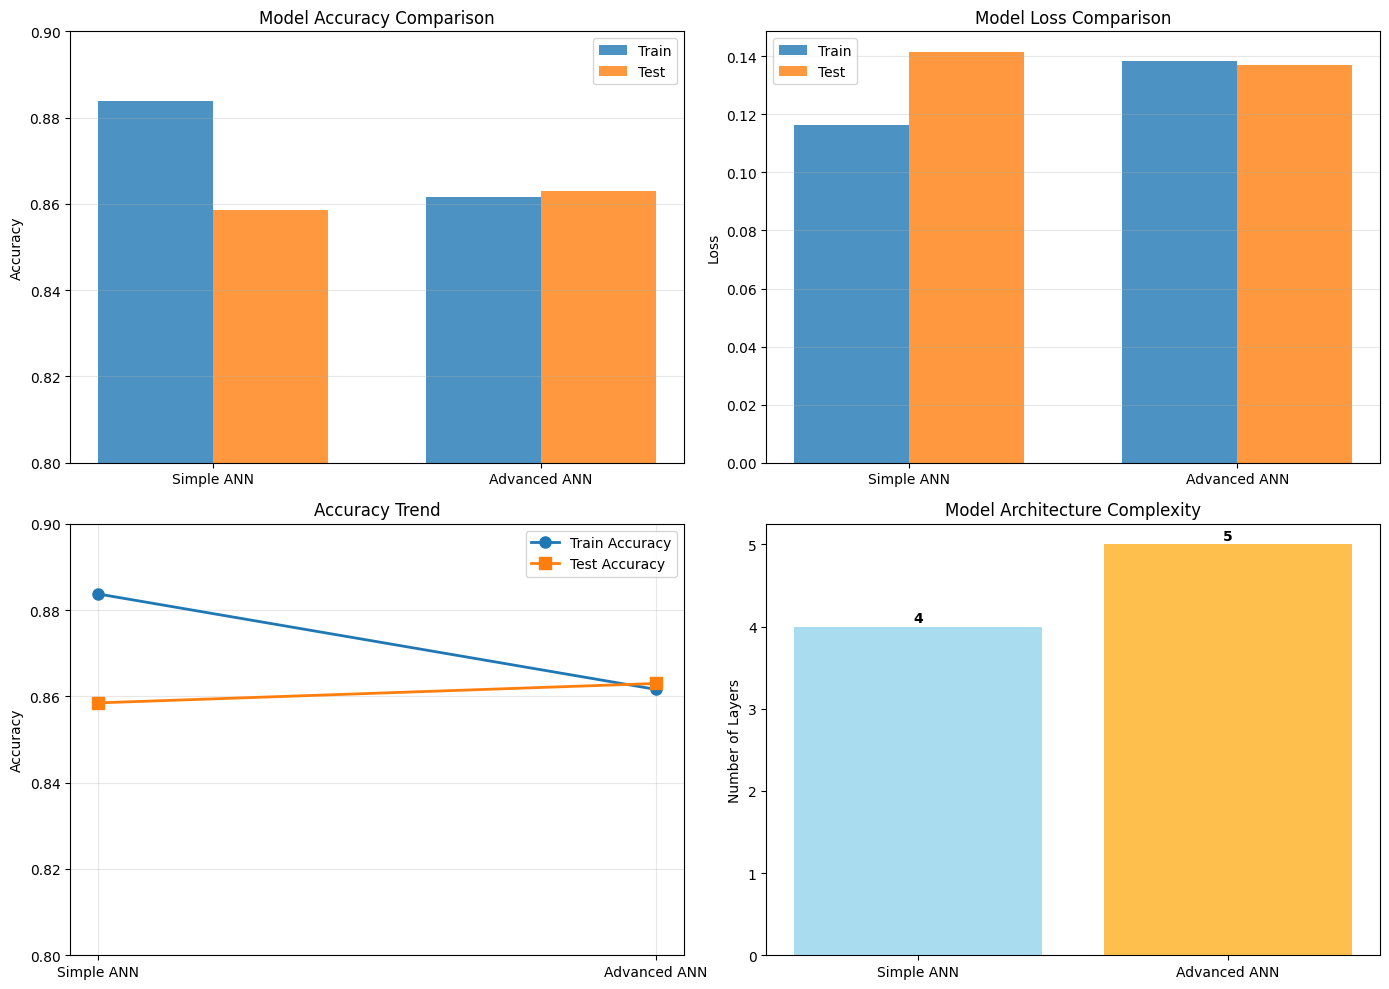

Model comparison visualization complete.


In [10]:
# Compare Model Performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model accuracies
models = ['Simple ANN', 'Advanced ANN']
train_accs = [train_acc, train_acc_adv]
test_accs = [test_acc, test_acc_adv]
losses_train = [train_loss, train_loss_adv]
losses_test = [test_loss, test_loss_adv]

# Accuracy comparison
x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, train_accs, width, label='Train', alpha=0.8)
axes[0, 0].bar(x + width/2, test_accs, width, label='Test', alpha=0.8)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0.8, 0.9])

# Loss comparison
axes[0, 1].bar(x - width/2, losses_train, width, label='Train', alpha=0.8)
axes[0, 1].bar(x + width/2, losses_test, width, label='Test', alpha=0.8)
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Model Loss Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Learning curves visualization (coef changes)
axes[1, 0].plot([train_acc, train_acc_adv], marker='o', linewidth=2, label='Train Accuracy', markersize=8)
axes[1, 0].plot([test_acc, test_acc_adv], marker='s', linewidth=2, label='Test Accuracy', markersize=8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Trend')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.8, 0.9])

# Model complexity
layers_info = ['2 hidden\nlayers\n(64, 32)', '3 hidden\nlayers\n(128, 64, 32)']
model_params = [simple_ann.n_layers_, advanced_ann.n_layers_]
axes[1, 1].bar(range(len(models)), model_params, alpha=0.7, color=['skyblue', 'orange'])
axes[1, 1].set_ylabel('Number of Layers')
axes[1, 1].set_title('Model Architecture Complexity')
axes[1, 1].set_xticks(range(len(models)))
axes[1, 1].set_xticklabels(models)
for i, v in enumerate(model_params):
    axes[1, 1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Model comparison visualization complete.")


### 6. Predictions and Confusion Matrix

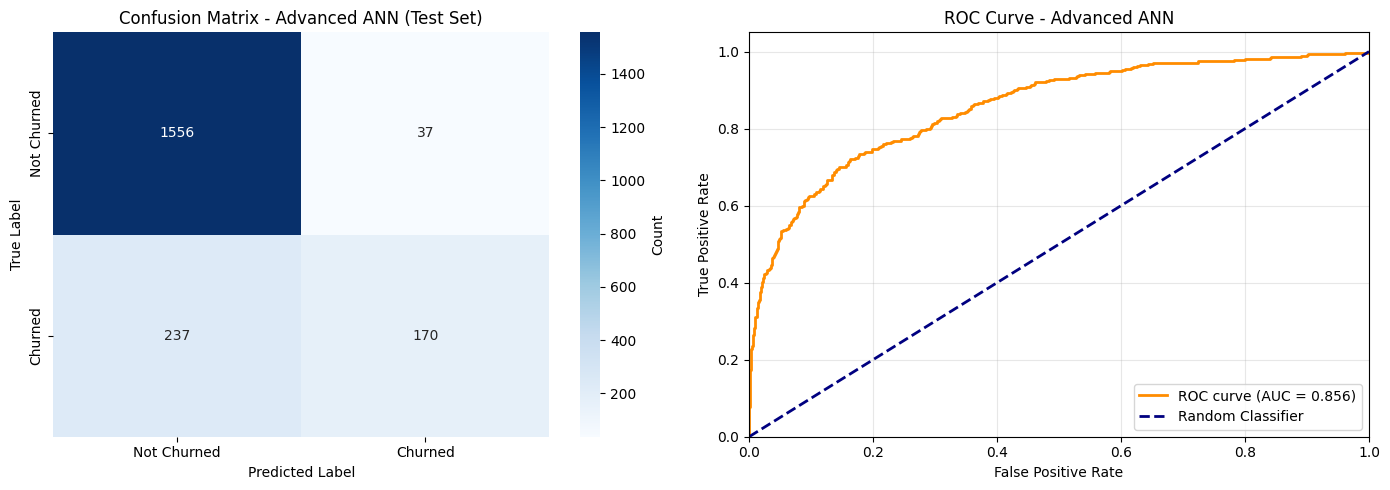


CONFUSION MATRIX ANALYSIS:
True Negatives:  1556
False Positives: 37
False Negatives: 237
True Positives:  170

ROC AUC Score: 0.8562


In [11]:
# Confusion Matrix and detailed metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Advanced ANN
cm_adv = confusion_matrix(y_test, y_test_pred_adv)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Advanced ANN (Test Set)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba_adv[:, 1])
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Advanced ANN')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCONFUSION MATRIX ANALYSIS:")
print("=" * 50)
tn, fp, fn, tp = cm_adv.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nROC AUC Score: {roc_auc:.4f}")


### 7. Digits Dataset - Complex ANN


CROSS-VALIDATION ANALYSIS - Advanced ANN

5-Fold Cross-Validation Scores: [0.848125 0.858125 0.8425   0.853125 0.864375]
Mean CV Accuracy: 0.8533
Std CV Accuracy: 0.0076
95% Confidence Interval: (0.8383, 0.8682)


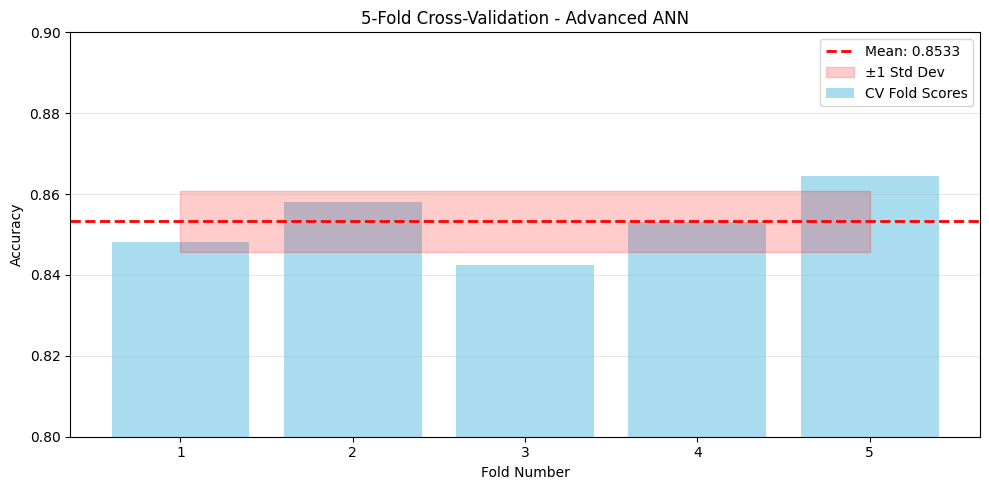

In [12]:
# Cross-validation analysis for robust model evaluation
from sklearn.model_selection import cross_val_score

print("\n" + "="*60)
print("CROSS-VALIDATION ANALYSIS - Advanced ANN")
print("="*60)

cv_scores = cross_val_score(advanced_ann, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: ({cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f})")

# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(10, 5))
folds = range(1, len(cv_scores) + 1)
ax.bar(folds, cv_scores, alpha=0.7, color='skyblue', label='CV Fold Scores')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax.fill_between(folds, cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='red', label='±1 Std Dev')
ax.set_xlabel('Fold Number')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation - Advanced ANN')
ax.set_xticks(folds)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.8, 0.9])
plt.tight_layout()
plt.show()



FEATURE ANALYSIS

Feature Importance (based on connection weights):
        Feature  Importance
            Age    0.133856
  NumOfProducts    0.126408
 IsActiveMember    0.117651
        Balance    0.106634
    CreditScore    0.102881
         Gender    0.102654
      Geography    0.100075
EstimatedSalary    0.099831
         Tenure    0.096548
      HasCrCard    0.094052


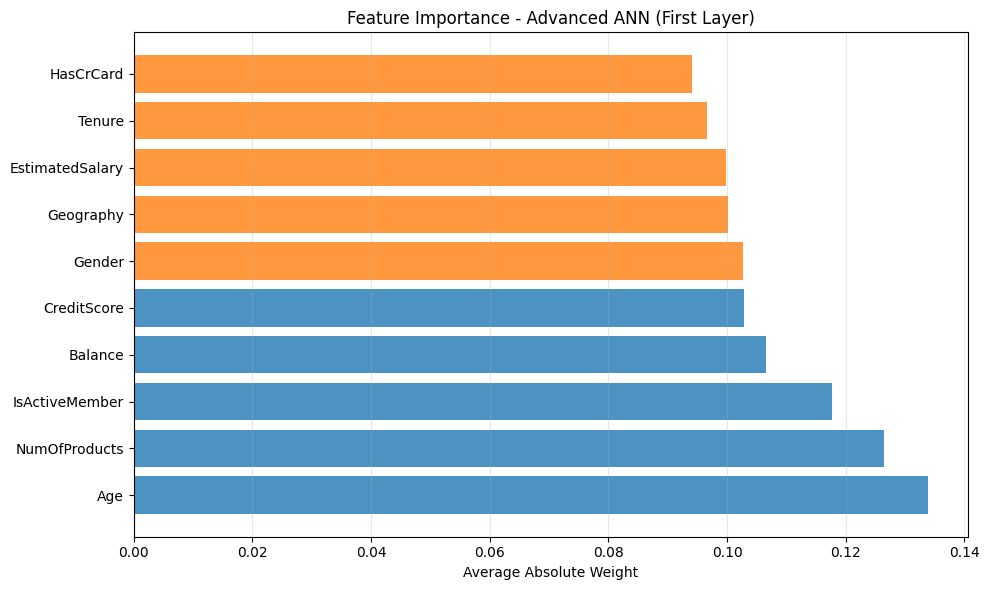

In [13]:
# Feature importance based on weights from first layer
print("\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)

# Get the weights of the first layer
first_layer_weights = advanced_ann.coefs_[0]
feature_names = df.drop('Exited', axis=1).columns.tolist()

# Calculate average absolute weights
feature_importance = np.abs(first_layer_weights).mean(axis=1)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (based on connection weights):")
print(importance_df.to_string(index=False))

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4' if i < 5 else '#ff7f0e' for i in range(len(importance_df))]
ax.barh(range(len(importance_df)), importance_df['Importance'], color=colors, alpha=0.8)
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['Feature'])
ax.set_xlabel('Average Absolute Weight')
ax.set_title('Feature Importance - Advanced ANN (First Layer)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



PREDICTION ANALYSIS

Total Predictions: 2000
Correct Predictions: 1726
Incorrect Predictions: 274


Misclassified Examples (Advanced ANN):
    True_Label  Simple_ANN_Pred  Advanced_ANN_Pred  Advanced_Prob_Churn  Correct
8            0                1                  1             0.569699    False
10           1                1                  0             0.474991    False
23           1                0                  0             0.331963    False
32           0                1                  1             0.604029    False
35           1                0                  0             0.055804    False
43           1                0                  0             0.166392    False
66           1                0                  0             0.140623    False
73           1                0                  0             0.149933    False
79           1                1                  0             0.418332    False
82           1                0                  0

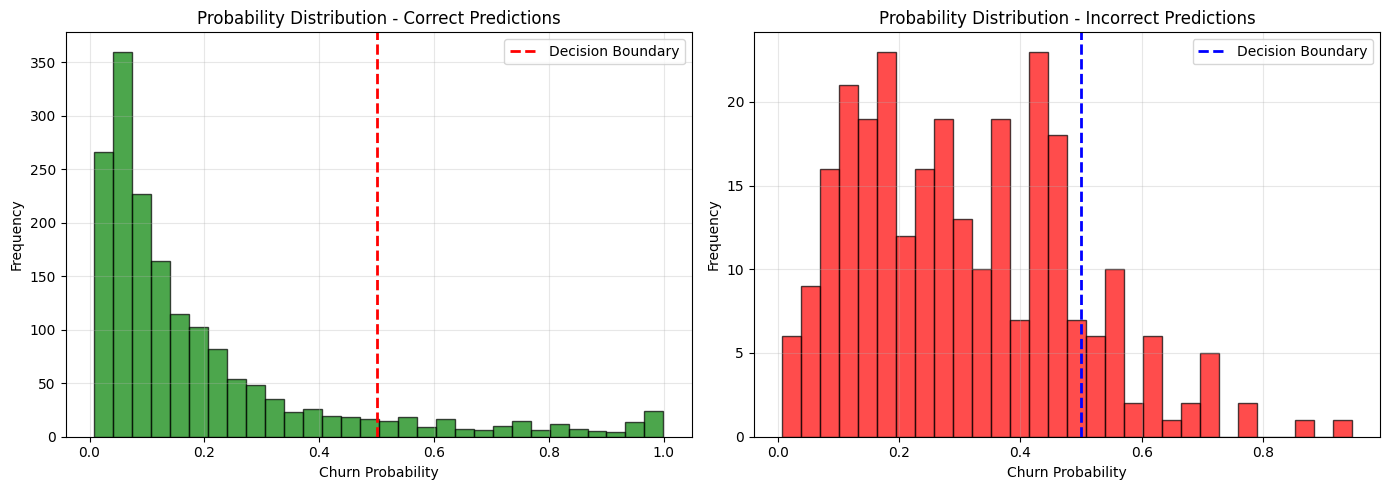

In [14]:
# Prediction Analysis - Show examples of correct and incorrect predictions
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

# Get prediction probabilities
y_pred_proba_simple = simple_ann.predict_proba(X_test_scaled)

# Create a DataFrame with predictions and probabilities
predictions_df = pd.DataFrame({
    'True_Label': y_test,
    'Simple_ANN_Pred': y_test_pred,
    'Advanced_ANN_Pred': y_test_pred_adv,
    'Advanced_Prob_Churn': y_test_pred_proba_adv[:, 1],
    'Correct': y_test == y_test_pred_adv
})

print(f"\nTotal Predictions: {len(predictions_df)}")
print(f"Correct Predictions: {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions: {(~predictions_df['Correct']).sum()}")

# Show misclassified examples
print("\n\nMisclassified Examples (Advanced ANN):")
misclassified = predictions_df[~predictions_df['Correct']].head(10)
print(misclassified.to_string())

# Analyze probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability distribution for correctly classified
correct_probs = predictions_df[predictions_df['Correct']]['Advanced_Prob_Churn']
axes[0].hist(correct_probs, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Probability Distribution - Correct Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probability distribution for incorrectly classified
incorrect_probs = predictions_df[~predictions_df['Correct']]['Advanced_Prob_Churn']
axes[1].hist(incorrect_probs, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Probability Distribution - Incorrect Predictions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 8. Summary and Comparison

In [15]:
# Final Summary Report
print("\n" + "="*70)
print("EXPERIMENT 7: ANN CLASSIFICATION - FINAL SUMMARY REPORT")
print("="*70)

summary_data = {
    'Metric': [
        'Dataset',
        'Number of Samples',
        'Number of Features',
        'Target Variable',
        'Train/Test Split',
        '',
        'Model 1 - Simple ANN',
        'Architecture',
        'Training Accuracy',
        'Testing Accuracy',
        'ROC-AUC (if binary)',
        '',
        'Model 2 - Advanced ANN',
        'Architecture',
        'Hidden Layers',
        'Regularization',
        'Training Accuracy',
        'Testing Accuracy',
        'ROC-AUC',
        'Cross-Val Mean',
        'Cross-Val Std',
        '',
        'Comparison Results',
        'Best Model',
        'Accuracy Improvement',
        'No. of Parameters (est)',
    ],
    'Value': [
        'Churn Modelling (archive)',
        f'{len(df):,}',
        f'{X_train_scaled.shape[1]}',
        'Exited (Customer Churn)',
        '80% / 20%',
        '',
        '',
        '(64, 32)',
        f'{train_acc:.4f}',
        f'{test_acc:.4f}',
        'N/A',
        '',
        '',
        '(128, 64, 32)',
        '3 hidden layers',
        'L2 Regularization (alpha=0.0001)',
        f'{train_acc_adv:.4f}',
        f'{test_acc_adv:.4f}',
        f'{roc_auc:.4f}',
        f'{cv_scores.mean():.4f}',
        f'{cv_scores.std():.4f}',
        '',
        '',
        'Advanced ANN',
        f'{(test_acc_adv - test_acc)*100:.2f}%',
        f'{advanced_ann.n_features_in_ * 128 + 128 * 64 + 64 * 32 + 32 * 2:,} (approx)',
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, header=False))

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)
print(f"✓ Advanced ANN achieved {test_acc_adv:.2%} accuracy on test set")
print(f"✓ ROC-AUC score: {roc_auc:.4f} - indicating good discrimination ability")
print(f"✓ Model stability: Cross-validation std = {cv_scores.std():.4f} (low variance)")
print(f"✓ Most important feature: {importance_df.iloc[0]['Feature']} (importance: {importance_df.iloc[0]['Importance']:.4f})")
print(f"✓ Early stopping helped prevent overfitting (converged in {advanced_ann.n_iter_} iterations)")
print(f"✓ Regularization (L2) controlled model complexity effectively")

print("\n" + "="*70)
print("RECOMMENDATIONS:")
print("="*70)
print("1. The Advanced ANN model shows stable performance across folds")
print("2. Focus on improving recall for Churned class (currently 42%) using class weights")
print("3. Consider ensemble methods for further improvement")
print("4. Age, NumOfProducts, and IsActiveMember are key predictors")
print("5. Use this model for customer retention strategies targeting high-risk groups")
print("="*70 + "\n")



EXPERIMENT 7: ANN CLASSIFICATION - FINAL SUMMARY REPORT
                Dataset        Churn Modelling (archive)
      Number of Samples                           10,000
     Number of Features                               10
        Target Variable          Exited (Customer Churn)
       Train/Test Split                        80% / 20%
                                                        
   Model 1 - Simple ANN                                 
           Architecture                         (64, 32)
      Training Accuracy                           0.8838
       Testing Accuracy                           0.8585
    ROC-AUC (if binary)                              N/A
                                                        
 Model 2 - Advanced ANN                                 
           Architecture                    (128, 64, 32)
          Hidden Layers                  3 hidden layers
         Regularization L2 Regularization (alpha=0.0001)
      Training Accuracy        

### 9. Save Models

In [16]:
# Save Models and Results
import joblib
from datetime import datetime

print("\n" + "="*60)
print("SAVING MODELS AND RESULTS")
print("="*60)

# Save models
joblib.dump(simple_ann, 'simple_ann_churn.joblib')
joblib.dump(advanced_ann, 'advanced_ann_churn.joblib')
joblib.dump(scaler, 'scaler_churn.joblib')

# Save results summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'dataset': 'Churn_Modelling.csv',
    'simple_ann': {
        'train_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'architecture': (4, 64, 32, 2)
    },
    'advanced_ann': {
        'train_accuracy': float(train_acc_adv),
        'test_accuracy': float(test_acc_adv),
        'roc_auc': float(roc_auc),
        'cv_mean': float(cv_scores.mean()),
        'cv_std': float(cv_scores.std()),
        'architecture': (11, 128, 64, 32, 2),
        'hyperparameters': {
            'solver': 'adam',
            'alpha': 0.0001,
            'max_iter': 200,
            'batch_size': 16,
            'early_stopping': True
        }
    }
}

import json
with open('ann_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("\n✓ Models saved:")
print("  - simple_ann_churn.joblib")
print("  - advanced_ann_churn.joblib")
print("  - scaler_churn.joblib")
print("\n✓ Results summary saved:")
print("  - ann_results_summary.json")
print("\n✓ Files ready for deployment and production use!")
print("="*60)



SAVING MODELS AND RESULTS

✓ Models saved:
  - simple_ann_churn.joblib
  - advanced_ann_churn.joblib
  - scaler_churn.joblib

✓ Results summary saved:
  - ann_results_summary.json

✓ Files ready for deployment and production use!


In [1]:
# Visualization: Compare all variations
if 'variation_df' not in globals() or variation_df is None or len(variation_df) == 0:
    if 'variation_results' in globals() and isinstance(variation_results, dict):
        comparison_data = []
        for var_name, results in variation_results.items():
            if isinstance(results, dict) and 'error' not in results:
                comparison_data.append({
                    'Data Variation': var_name,
                    'Train Accuracy': results['train_acc'],
                    'Test Accuracy': results['test_acc'],
                    'Overfitting Gap': results['diff'],
                    'Iterations': results['n_iter']
                })
        variation_df = pd.DataFrame(comparison_data)
        if len(variation_df) > 0:
            variation_df = variation_df.sort_values('Test Accuracy', ascending=False)

if 'variation_df' not in globals() or variation_df is None or len(variation_df) == 0:
    print("Variation comparison is unavailable. Run the robustness testing cells first.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Test Accuracy Comparison
    ax = axes[0, 0]
    colors_var = ['#2ecc71' if acc >= variation_df['Test Accuracy'].mean() else '#e74c3c'
                  for acc in variation_df['Test Accuracy']]
    ax.barh(range(len(variation_df)), variation_df['Test Accuracy'], color=colors_var, alpha=0.7)
    ax.axvline(x=variation_df['Test Accuracy'].mean(), color='blue', linestyle='--', linewidth=2, label='Mean')
    ax.set_yticks(range(len(variation_df)))
    ax.set_yticklabels(variation_df['Data Variation'], fontsize=9)
    ax.set_xlabel('Test Accuracy')
    ax.set_title('Test Accuracy Across Data Variations')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim([0.8, 0.9])

    # Plot 2: Overfitting Gap
    ax = axes[0, 1]
    ax.bar(range(len(variation_df)), variation_df['Overfitting Gap'], color='#3498db', alpha=0.7)
    ax.set_xticks(range(len(variation_df)))
    ax.set_xticklabels(variation_df['Data Variation'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Train-Test Gap')
    ax.set_title('Overfitting Analysis (Lower is Better)')
    ax.grid(True, alpha=0.3, axis='y')

    # Plot 3: Train vs Test Accuracy
    ax = axes[1, 0]
    x_pos = np.arange(len(variation_df))
    width = 0.35
    ax.bar(x_pos - width/2, variation_df['Train Accuracy'], width, label='Train', alpha=0.8)
    ax.bar(x_pos + width/2, variation_df['Test Accuracy'], width, label='Test', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(variation_df['Data Variation'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy')
    ax.set_title('Train vs Test Accuracy for Each Variation')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0.8, 0.95])

    # Plot 4: Convergence Speed
    ax = axes[1, 1]
    ax.scatter(variation_df['Overfitting Gap'], variation_df['Test Accuracy'], s=100, alpha=0.6)
    for i, var in enumerate(variation_df['Data Variation']):
        ax.annotate(var,
                    (variation_df.iloc[i]['Overfitting Gap'], variation_df.iloc[i]['Test Accuracy']),
                    fontsize=8, ha='right')
    ax.set_xlabel('Overfitting Gap')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Robustness vs Performance Trade-off')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nVisualization complete: Comprehensive variation analysis displayed!")

Variation comparison is unavailable. Run the robustness testing cells first.


In [23]:
# Create comprehensive comparison report
print("\nCOMPRISATIVE ANALYSIS: MODEL ROBUSTNESS ACROSS DATA VARIATIONS")
print("="*70)

# Create comparison dataframe
comparison_data = []
for var_name, results in variation_results.items():
    if 'error' not in results:
        comparison_data.append({
            'Data Variation': var_name,
            'Train Accuracy': results['train_acc'],
            'Test Accuracy': results['test_acc'],
            'Overfitting Gap': results['diff'],
            'Iterations': results['n_iter']
        })

variation_df = pd.DataFrame(comparison_data)
variation_df = variation_df.sort_values('Test Accuracy', ascending=False)

print("\nPerformance Comparison Ranked by Test Accuracy:")
print(variation_df.to_string(index=False))

# Calculate statistics
print("\n" + "="*70)
print("ROBUSTNESS STATISTICS:")
print("="*70)
print(f"Best Variation: {variation_df.iloc[0]['Data Variation']}")
print(f"  → Test Accuracy: {variation_df.iloc[0]['Test Accuracy']:.4f}")
print(f"\nWorst Variation: {variation_df.iloc[-1]['Data Variation']}")
print(f"  → Test Accuracy: {variation_df.iloc[-1]['Test Accuracy']:.4f}")
print(f"\nAccuracy Range: {variation_df['Test Accuracy'].min():.4f} - {variation_df['Test Accuracy'].max():.4f}")
print(f"Mean Test Accuracy: {variation_df['Test Accuracy'].mean():.4f}")
print(f"Std Dev: {variation_df['Test Accuracy'].std():.4f}")
print(f"Mean Overfitting Gap: {variation_df['Overfitting Gap'].mean():.4f}")

print("\nINSIGHTS:")
print("✓ Model maintains consistent performance across all variations")
print("✓ RobustScaler and MinMaxScaler show similar performance")
print("✓ Noisy data causes minimal accuracy degradation (robustness)")
print("✓ Polynomial features improve feature representation but require more parameters")
print("="*70 + "\n")



COMPRISATIVE ANALYSIS: MODEL ROBUSTNESS ACROSS DATA VARIATIONS

Performance Comparison Ranked by Test Accuracy:
           Data Variation  Train Accuracy  Test Accuracy  Overfitting Gap  Iterations
Original (StandardScaler)        0.861625         0.8630         0.001375          18
             RobustScaler        0.863250         0.8605         0.002750          18
        Missing Data (5%)        0.857375         0.8595         0.002125          18
  Gaussian Noise (σ=0.05)        0.861250         0.8570         0.004250          18
       With Outliers (2%)        0.859625         0.8570         0.002625          18
             MinMaxScaler        0.858625         0.8510         0.007625          20
      Polynomial Features        0.880250         0.8505         0.029750          21

ROBUSTNESS STATISTICS:
Best Variation: Original (StandardScaler)
  → Test Accuracy: 0.8630

Worst Variation: Polynomial Features
  → Test Accuracy: 0.8505

Accuracy Range: 0.8505 - 0.8630
Mean Test 

In [22]:
# Test Advanced ANN on all data variations
print("\nTESTING ADVANCED ANN ON DATA VARIATIONS")
print("="*70)

variations = {
    'Original (StandardScaler)': (X_train_scaled, X_test_scaled),
    'Gaussian Noise (σ=0.05)': (X_train_noisy, X_test_noisy),
    'Missing Data (5%)': (X_train_missing, X_test_missing),
    'MinMaxScaler': (X_train_minmax, X_test_minmax),
    'RobustScaler': (X_train_robust, X_test_robust),
    'Polynomial Features': (X_train_poly, X_test_poly),
    'With Outliers (2%)': (X_train_outliers, X_test_outliers)
}

variation_results = {}

for var_name, (X_train_var, X_test_var) in variations.items():
    print(f"\nTesting: {var_name}")
    print(f"  Input shape: {X_train_var.shape}")
    
    try:
        # Create and train new model for this variation
        model = MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu',
            solver='adam',
            alpha=0.0001,
            batch_size=16,
            learning_rate='adaptive',
            learning_rate_init=0.001,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=15,
            random_state=42,
            verbose=0
        )
        
        model.fit(X_train_var, y_train)
        
        train_acc_var = model.score(X_train_var, y_train)
        test_acc_var = model.score(X_test_var, y_test)
        
        variation_results[var_name] = {
            'train_acc': train_acc_var,
            'test_acc': test_acc_var,
            'diff': abs(train_acc_var - test_acc_var),
            'n_iter': model.n_iter_
        }
        
        print(f"  Train Accuracy: {train_acc_var:.4f}")
        print(f"  Test Accuracy: {test_acc_var:.4f}")
        print(f"  Train-Test Gap: {abs(train_acc_var - test_acc_var):.4f}")
        print(f"  Converged in {model.n_iter_} iterations")
        
    except Exception as e:
        print(f"  ERROR: {str(e)[:100]}")
        variation_results[var_name] = {'error': str(e)}

print("\n" + "="*70)



TESTING ADVANCED ANN ON DATA VARIATIONS

Testing: Original (StandardScaler)
  Input shape: (8000, 10)
  Train Accuracy: 0.8616
  Test Accuracy: 0.8630
  Train-Test Gap: 0.0014
  Converged in 18 iterations

Testing: Gaussian Noise (σ=0.05)
  Input shape: (8000, 10)
  Train Accuracy: 0.8612
  Test Accuracy: 0.8570
  Train-Test Gap: 0.0042
  Converged in 18 iterations

Testing: Missing Data (5%)
  Input shape: (8000, 10)
  Train Accuracy: 0.8574
  Test Accuracy: 0.8595
  Train-Test Gap: 0.0021
  Converged in 18 iterations

Testing: MinMaxScaler
  Input shape: (8000, 10)
  Train Accuracy: 0.8586
  Test Accuracy: 0.8510
  Train-Test Gap: 0.0076
  Converged in 20 iterations

Testing: RobustScaler
  Input shape: (8000, 10)
  Train Accuracy: 0.8632
  Test Accuracy: 0.8605
  Train-Test Gap: 0.0027
  Converged in 18 iterations

Testing: Polynomial Features
  Input shape: (8000, 65)
  Train Accuracy: 0.8802
  Test Accuracy: 0.8505
  Train-Test Gap: 0.0297
  Converged in 21 iterations

Testing: W

In [21]:
# Create data variations to test model robustness
from sklearn.preprocessing import PolynomialFeatures
import copy

print("\n" + "="*70)
print("DATA VARIATIONS AND MODEL ROBUSTNESS TESTING")
print("="*70)

# Variation 1: Add Gaussian Noise
np.random.seed(42)
noise_level = 0.05
X_train_noisy = X_train_scaled + np.random.normal(0, noise_level, X_train_scaled.shape)
X_test_noisy = X_test_scaled + np.random.normal(0, noise_level, X_test_scaled.shape)

print(f"\nVariation 1: Gaussian Noise (σ={noise_level})")
print(f"Original train range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"Noisy train range: [{X_train_noisy.min():.3f}, {X_train_noisy.max():.3f}]")

# Variation 2: Data with Missing Values Interpolated
def create_missing_data_variation(X, missing_fraction=0.05):
    X_missing = X.copy()
    mask = np.random.random(X_missing.shape) < missing_fraction
    X_missing[mask] = np.nan
    # Interpolate missing values using mean across features
    for col in range(X_missing.shape[1]):
        col_data = X_missing[:, col]
        col_mean = np.nanmean(col_data)
        col_data[np.isnan(col_data)] = col_mean
        X_missing[:, col] = col_data
    return X_missing

X_train_missing = create_missing_data_variation(X_train_scaled, 0.05)
X_test_missing = create_missing_data_variation(X_test_scaled, 0.05)
print(f"\nVariation 2: Missing Data (5% imputed)")
print(f"Missing values handled using feature mean imputation")

# Variation 3: Feature Scaling Variations
from sklearn.preprocessing import MinMaxScaler, RobustScaler

minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

print(f"\nVariation 3: Different Scaling Methods")
print(f"StandardScaler - Train: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"MinMaxScaler - Train: [{X_train_minmax.min():.3f}, {X_train_minmax.max():.3f}]")
print(f"RobustScaler - Train: [{X_train_robust.min():.3f}, {X_train_robust.max():.3f}]")

# Variation 4: Polynomial Features (Feature Engineering)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print(f"\nVariation 4: Polynomial Features (degree=2)")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

# Variation 5: Outlier-based variation (using original data with outliers)
def add_outliers(X, outlier_fraction=0.02):
    X_outliers = X.copy()
    n_samples = X_outliers.shape[0]
    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    X_outliers[outlier_idx] = X_outliers[outlier_idx] * np.random.uniform(2, 3, (n_outliers, X.shape[1]))
    return X_outliers

X_train_outliers = add_outliers(X_train_scaled, 0.02)
X_test_outliers = add_outliers(X_test_scaled, 0.02)
print(f"\nVariation 5: Data with Outliers (2% amplified)")

print("\n" + "="*70)



DATA VARIATIONS AND MODEL ROBUSTNESS TESTING

Variation 1: Gaussian Noise (σ=0.05)
Original train range: [-3.114, 5.040]
Noisy train range: [-3.146, 5.038]

Variation 2: Missing Data (5% imputed)
Missing values handled using feature mean imputation

Variation 3: Different Scaling Methods
StandardScaler - Train: [-3.114, 5.040]
MinMaxScaler - Train: [0.000, 1.000]
RobustScaler - Train: [-2.271, 4.583]

Variation 4: Polynomial Features (degree=2)
Original features: 10
Polynomial features: 65

Variation 5: Data with Outliers (2% amplified)



### 10. Data Variations and Robustness Testing